In [2]:
from google.colab import files
uploaded = files.upload()

Saving darkimage.jpg to darkimage.jpg


In [4]:
dark_image = load_grayscale(list(uploaded.keys())[0])

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
dark_image = load_grayscale('/content/drive/MyDrive/Colab_Images/darkimage.jpg')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Original range: 0.000 - 0.385
Stretched range: 0.000 - 1.000


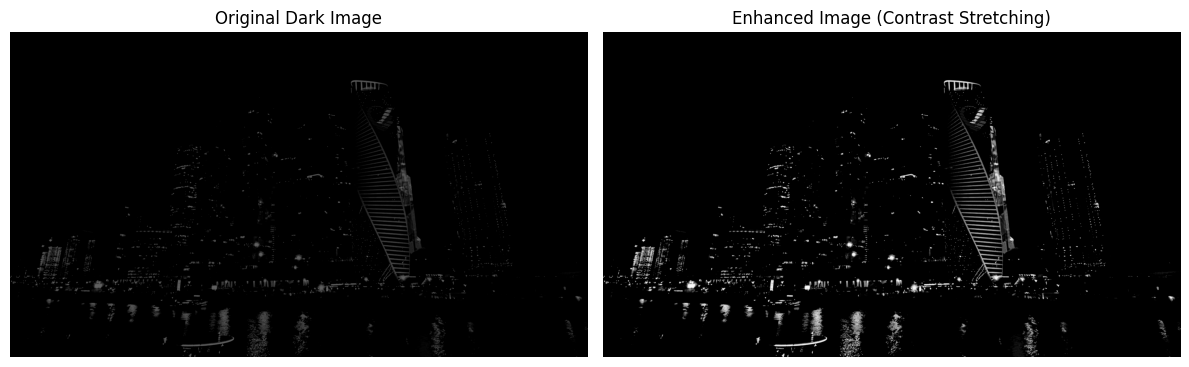

In [8]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import matplotlib.pyplot as plt

def load_grayscale(file):
    image = plt.imread(file)
    if image.dtype == np.uint8:
        image = image / 255.0

    if len(image.shape) == 2:
        return image
    elif len(image.shape) == 3:
        if image.shape[2] == 3:
            return image @ (0.2989, 0.5870, 0.1140)
        elif image.shape[2] == 4:
            return image[..., :3] @ (0.2989, 0.5870, 0.1140) * image[..., 3]

    raise ValueError("Unsupported image format")

def contrast_stretch(image):
    min_val = np.min(image)
    max_val = np.max(image)

    print(f"Original range: {min_val:.3f} - {max_val:.3f}")

    stretched = (image - min_val) / (max_val - min_val)

    print(f"Stretched range: {np.min(stretched):.3f} - {np.max(stretched):.3f}")

    return stretched

dark_image = load_grayscale('/content/drive/MyDrive/Colab_Images/darkimage.jpg')

enhanced_image = contrast_stretch(dark_image)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.imshow(dark_image, cmap='gray', vmin=0, vmax=1)
ax1.set_title('Original Dark Image')
ax1.axis('off')

ax2.imshow(enhanced_image, cmap='gray', vmin=0, vmax=1)
ax2.set_title('Enhanced Image (Contrast Stretching)')
ax2.axis('off')

plt.tight_layout()
plt.show()